# Chapter 24 — CoAP Protocol: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks at the end of each section. All exercises run in Google
> Colab with no additional hardware or live network connection — every
> exchange is a self-contained simulation built directly from the CoAP
> wire format and timing rules in RFC 7252, RFC 7641, and RFC 7959.

| Exercise | Topic | Key technique |
|----------|-------|----------------|
| 24.1 | CoAP vs. HTTP framing, payload/option sweeps | Byte-exact encoder with the full RFC 7252 §3.1 option-length escape (both extension tiers) |
| 24.2 | CON vs. NON, apples-to-apples | Same underlying exchange for both message types; only retry behaviour differs |
| 24.3 | Observe: a full lifecycle model | Renewal-process traffic model, byte-exact per-message-type accounting, OSN reordering |
| 24.4 | Blockwise Transfer block size | Asymmetric frame-size-dependent loss, explicit transfer success/failure tracking |


---
## Setup

This cell builds the shared toolkit used throughout the notebook: a
byte-exact CoAP message encoder implementing **both** tiers of RFC 7252
§3.1's option-length extension, covering the full representable range
up to 65804, an HTTP/1.1 message builder, the RFC 7252 §4.8
default transmission parameters, and a frame-size-dependent loss model
reused, with different calibration, in Exercises 24.2–24.4.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (12, 5), 'axes.grid': True,
                      'grid.alpha': 0.3, 'font.size': 10.5})

# ---------------------------------------------------------------------
# Core CoAP encoder (RFC 7252 Sec. 3), with the FULL option-length escape
# ---------------------------------------------------------------------
def _nibble_and_extension(v):
    """RFC 7252 Sec. 3.1's full 3-tier escape for an option delta/length:
       v < 13        -> nibble = v, no extension
       13 <= v < 269   -> nibble = 13, 1 extension byte  = v - 13
       269 <= v < 65805 -> nibble = 14, 2 extension bytes = v - 269 (big-endian)
    """
    if v < 13:    return v, b""
    if v < 269:   return 13, bytes([v - 13])
    if v < 65805: return 14, (v - 269).to_bytes(2, "big")
    raise ValueError("delta/length exceeds RFC 7252's representable maximum")

def encode_option_header(delta, length):
    dn, dext = _nibble_and_extension(delta)
    ln, lext = _nibble_and_extension(length)
    return bytes([(dn << 4) | ln]) + dext + lext

def encode_coap_message(msg_type, code_byte, message_id, token, options, payload=b""):
    """Byte-exact CoAP message encoder (RFC 7252 Sec. 3)."""
    header = bytes([(0b01 << 6) | (msg_type << 4) | len(token)])   # Ver = 01
    header += bytes([code_byte]) + message_id.to_bytes(2, "big")
    out = bytearray(header + token)
    running = 0
    for opt_num, value in options:                # ascending option-number order
        out += encode_option_header(opt_num - running, len(value))
        out += value
        running = opt_num
    if payload:
        out += bytes([0xFF]) + payload
    return bytes(out)

def coap_code(cls, detail):
    return (cls << 5) | detail

def uint_option_value(n):
    """RFC 7252 Sec. 3.2 integer option: shortest big-endian form, empty for 0."""
    if n == 0:
        return b""
    length = (n.bit_length() + 7) // 8
    return n.to_bytes(length, "big")

# Regression check: verify the extended-length escape at delta/length >= 269
_h = encode_option_header(300, 0)
assert len(_h) == 3 and (_h[0] >> 4) == 14 and int.from_bytes(_h[1:3], "big") == 300 - 269
print("Option encoder regression check passed (nibble-13 and nibble-14 both verified).")


# ---------------------------------------------------------------------
# Exercise 24.1: parametric CoAP / HTTP exchange builders
# ---------------------------------------------------------------------
def build_coap_exchange(uri_segments=("sensors", "temperature"), token_len=2, payload=b"22.5"):
    token = bytes(range(1, token_len + 1))
    message_id = 0xBC90
    req_options = [(11, seg.encode()) for seg in uri_segments]
    request = encode_coap_message(0, coap_code(0, 1), message_id, token, req_options)
    resp_options = [(12, uint_option_value(0))]
    response = encode_coap_message(2, coap_code(2, 5), message_id, token, resp_options, payload)
    return request, response

def build_http_exchange(host="iot.example.com", path="/sensors/temperature", body=b"22.5"):
    request = (f"GET {path} HTTP/1.1\r\nHost: {host}\r\nAccept: text/plain\r\n"
               f"Connection: keep-alive\r\n\r\n").encode("ascii")
    response = (f"HTTP/1.1 200 OK\r\nContent-Type: text/plain\r\nContent-Length: {len(body)}\r\n"
                f"Connection: keep-alive\r\n\r\n").encode("ascii") + body
    return request, response

UDP_HDR, IPV4_HDR, TCP_HDR_MIN = 8, 20, 20

def coap_wire_bytes(req, resp):
    per_dgram = UDP_HDR + IPV4_HDR
    return (len(req) + per_dgram) + (len(resp) + per_dgram)

def http_wire_bytes_persistent(req, resp):
    per_seg = TCP_HDR_MIN + IPV4_HDR
    return (len(req) + per_seg) + (len(resp) + per_seg)

def http_handshake_bytes():
    return 3 * (TCP_HDR_MIN + IPV4_HDR)

def http_wire_bytes_new_connection(req, resp):
    return http_wire_bytes_persistent(req, resp) + http_handshake_bytes()

def build_discovery_exchange():
    """RFC 6690 CoRE Link Format discovery of two resources."""
    token = bytes([0x7A]); message_id = 0x4321
    request = encode_coap_message(0, coap_code(0, 1), message_id, token,
                                   [(11, b".well-known"), (11, b"core")])
    payload = (b'</sensors/temperature>;rt="temperature-c";if="sensor",'
               b'</sensors/humidity>;rt="humidity-pct";if="sensor"')
    response = encode_coap_message(2, coap_code(2, 5), message_id, token,
                                    [(12, uint_option_value(40))], payload)
    return request, response


# ---------------------------------------------------------------------
# Exercises 24.2 & 24.4: RFC 7252 Sec. 4.8 default transmission parameters
# ---------------------------------------------------------------------
ACK_TIMEOUT = 2.0
ACK_RANDOM_FACTOR = 1.5
MAX_RETRANSMIT = 4
BASE_RTT = 0.08

print("Setup complete.")
req, resp = build_coap_exchange()
print(f"CoAP GET/2.05 exchange: message layer = {len(req)+len(resp)} B, "
      f"UDP/IPv4 wire = {coap_wire_bytes(req, resp)} B")

Option encoder regression check passed (nibble-13 and nibble-14 both verified).
Setup complete.
CoAP GET/2.05 exchange: message layer = 38 B, UDP/IPv4 wire = 94 B


---
## Exercise 24.1 — CoAP vs. HTTP: Framing Overhead Across Protocol-Stack Levels

### Background

CoAP was designed as a direct answer to a specific question: what would
HTTP's request/response, RESTful style look like if it had to run on an
8-bit microcontroller with a few kilobytes of RAM, talking over a lossy
radio link, instead of a data-centre server with a reliable Ethernet
connection? This exercise builds a byte-exact encoder for both protocols
and compares them for an equivalent exchange at three protocol-stack
levels, then extends the comparison along two further axes — response
payload size and number of URI segments/options — since a single
fixed-payload comparison risks implying a fixed percentage saving that
does not actually hold as those parameters change.

**Accounting boundary, stated explicitly.** The wire-level figures below
are a *simplified* transport/network-layer estimate: one UDP or TCP
header plus one IPv4 header per datagram, plus (for a new TCP
connection) the three-segment handshake. Deliberately **not** counted:
pure TCP ACKs, TCP teardown, TCP options, retransmissions, link-layer
framing, and DTLS/TLS (discussed qualitatively at the end). The
persistent-HTTP case is a steady-state model: its one-time handshake
cost is never repeated per exchange.

In [2]:
# ── Exercise 24.1: baseline byte-exact framing ─────────────────────────
req, resp = build_coap_exchange()
hreq, hresp = build_http_exchange()

coap_layer = len(req) + len(resp)
coap_wire = coap_wire_bytes(req, resp)
http_layer = len(hreq) + len(hresp)
http_wire_persist = http_wire_bytes_persistent(hreq, hresp)
http_wire_new = http_wire_bytes_new_connection(hreq, hresp)

print("CoAP request  :", len(req), "B  ->", req.hex())
print("CoAP response :", len(resp), "B ->", resp.hex())
print(f"CoAP  message layer = {coap_layer} B   |  UDP/IPv4 wire = {coap_wire} B")
print(f"HTTP  message layer = {http_layer} B   |  TCP/IPv4 wire (persistent) = {http_wire_persist} B"
      f"  |  (new connection) = {http_wire_new} B")
print(f"Message-layer saving: {100*(1-coap_layer/http_layer):.1f}%")
print(f"Wire-level saving (persistent HTTP): {100*(1-coap_wire/http_wire_persist):.1f}% "
      f"({http_wire_persist/coap_wire:.2f}x)")
print(f"Wire-level saving (new-connection HTTP): {100*(1-coap_wire/http_wire_new):.1f}% "
      f"({http_wire_new/coap_wire:.2f}x)")

dreq, dresp = build_discovery_exchange()
print(f"\nResource discovery: GET /.well-known/core = {len(dreq)} B, "
      f"response = {len(dresp)} B, total = {len(dreq)+len(dresp)} B")

CoAP request  : 26 B  -> 4201bc900102b773656e736f72730b74656d7065726174757265
CoAP response : 12 B -> 6245bc900102c0ff32322e35
CoAP  message layer = 38 B   |  UDP/IPv4 wire = 94 B
HTTP  message layer = 196 B   |  TCP/IPv4 wire (persistent) = 276 B  |  (new connection) = 396 B
Message-layer saving: 80.6%
Wire-level saving (persistent HTTP): 65.9% (2.94x)
Wire-level saving (new-connection HTTP): 76.3% (4.21x)

Resource discovery: GET /.well-known/core = 22 B, response = 111 B, total = 133 B


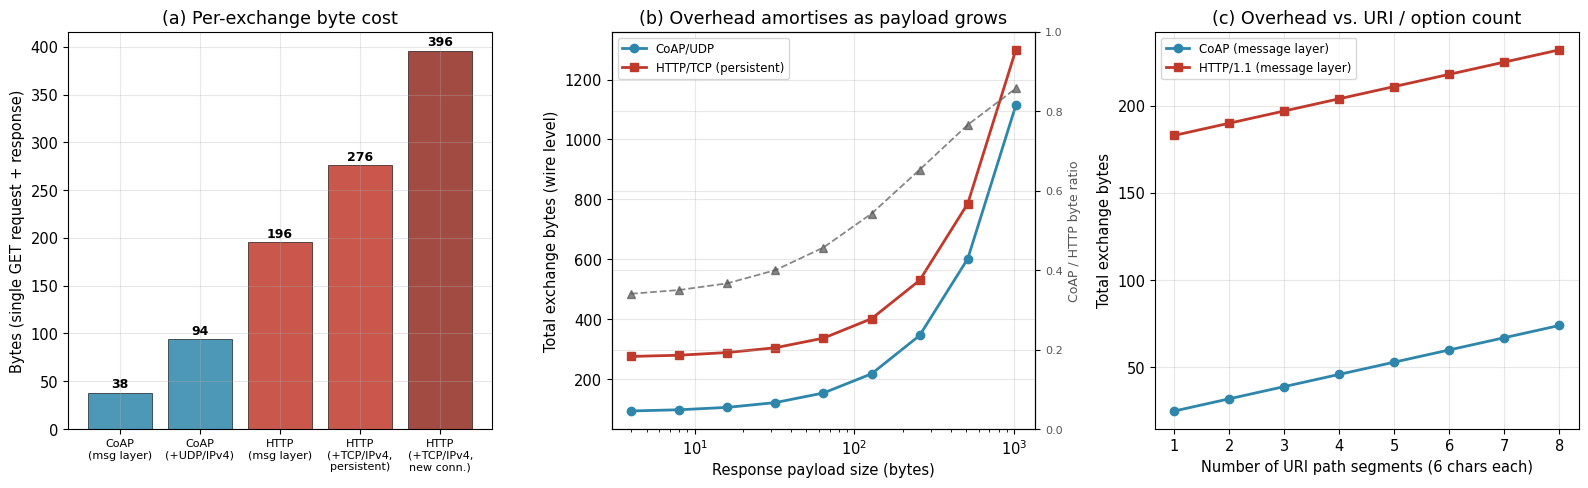

ratio @4B: 0.34057971014492755  ratio @1024B: 0.8575827559661278


In [3]:
# ── Figure 24.1: per-exchange bytes, payload sweep, URI/option-count sweep ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) per-exchange bytes at protocol-stack levels
ax = axes[0]
labels = ['CoAP\n(msg layer)', 'CoAP\n(+UDP/IPv4)', 'HTTP\n(msg layer)',
          'HTTP\n(+TCP/IPv4,\npersistent)', 'HTTP\n(+TCP/IPv4,\nnew conn.)']
values = [coap_layer, coap_wire, http_layer, http_wire_persist, http_wire_new]
colors = ['#2E86AB', '#2E86AB', '#C0392B', '#C0392B', '#922B21']
bars = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 5, str(v), ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Bytes (single GET request + response)')
ax.set_title('(a) Per-exchange byte cost')
ax.tick_params(axis='x', labelsize=8)

# (b) total bytes vs. response payload size
ax = axes[1]
payload_sizes = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])
coap_tot, http_tot = [], []
for pl in payload_sizes:
    payload = b"x" * int(pl)
    r, s = build_coap_exchange(payload=payload)
    hr, hs = build_http_exchange(body=payload)
    coap_tot.append(coap_wire_bytes(r, s))
    http_tot.append(http_wire_bytes_persistent(hr, hs))
coap_tot, http_tot = np.array(coap_tot), np.array(http_tot)
ax.plot(payload_sizes, coap_tot, 'o-', color='#2E86AB', lw=2, label='CoAP/UDP')
ax.plot(payload_sizes, http_tot, 's-', color='#C0392B', lw=2, label='HTTP/TCP (persistent)')
ax.set_xscale('log')
ax.set_xlabel('Response payload size (bytes)'); ax.set_ylabel('Total exchange bytes (wire level)')
ax.set_title('(b) Overhead amortises as payload grows'); ax.legend(fontsize=8.5)
axb2 = ax.twinx()
axb2.plot(payload_sizes, coap_tot / http_tot, '^--', color='#555555', lw=1.3, alpha=0.7)
axb2.set_ylabel('CoAP / HTTP byte ratio', color='#555555', fontsize=9)
axb2.tick_params(axis='y', labelcolor='#555555', labelsize=8); axb2.set_ylim(0, 1)

# (c) total bytes vs. number of Uri-Path segments
ax = axes[2]
n_segs = np.arange(1, 9)
coap_msg, http_msg = [], []
for n in n_segs:
    segs = tuple(f"seg{i:03d}" for i in range(n))
    path = "/" + "/".join(segs)
    r, s = build_coap_exchange(uri_segments=segs)
    hr, hs = build_http_exchange(path=path)
    coap_msg.append(len(r) + len(s)); http_msg.append(len(hr) + len(hs))
ax.plot(n_segs, coap_msg, 'o-', color='#2E86AB', lw=2, label='CoAP (message layer)')
ax.plot(n_segs, http_msg, 's-', color='#C0392B', lw=2, label='HTTP/1.1 (message layer)')
ax.set_xlabel('Number of URI path segments (6 chars each)'); ax.set_ylabel('Total exchange bytes')
ax.set_title('(c) Overhead vs. URI / option count'); ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig('fig_24_1_coap_http_overhead.png', dpi=300, bbox_inches='tight')
plt.show()
print("ratio @4B:", coap_tot[0]/http_tot[0], " ratio @1024B:", coap_tot[-1]/http_tot[-1])

### Analysis

**Figure 24.1(a)** establishes the baseline: a complete CoAP GET/response
exchange costs 38 B against HTTP/1.1's 196 B at the message layer
(80.6% reduction), and 94 B against 276 B (persistent) or 396 B (new
connection) at the simplified wire level — a 2.9× and 4.2× reduction
respectively.

**Figure 24.1(b)** shows this is not a fixed property of the two
protocols: as response payload grows from 4 B to 1024 B, the CoAP/HTTP
ratio rises from 0.34 to 0.86 — CoAP's relative advantage is largest
for the small, frequent, low-payload exchanges typical of constrained
devices, and smallest as an exchange approaches Blockwise Transfer
territory (Exercise 24.4).

**Figure 24.1(c)** shows the opposite sensitivity: as URI depth grows
from 1 to 8 segments, both protocols grow by the same 49 B absolute
amount, but that is a much larger *relative* change for CoAP's small
base size — so CoAP's proportional advantage actually **narrows**, not
widens, as URI paths get deeper. "CoAP is smaller" needs a stated
payload and URI shape to mean anything precise.

**Resource discovery** (`.well-known/core`, RFC 6690) uses exactly the
same encoder and framing rules as the worked example — no separate
protocol machinery is required.

**A note on security overhead.** This exercise deliberately compares
CoAP over UDP against HTTP over TCP without DTLS or TLS on either side.
A minimal PSK-based DTLS 1.3 handshake and a TLS 1.3 handshake are
structurally similar (typically one round trip); adding security raises
both protocols' totals without reversing which one carries the larger
baseline overhead.

> **Key takeaway.** CoAP's overhead advantage over HTTP is real but not
> a fixed percentage: largest for small, frequent exchanges, shrinking
> as payload grows, and narrowing (not widening) as URI paths deepen.

### Challenge tasks

1. Recompute the message-layer byte counts for a `PUT` request writing a
   new setpoint (2-byte payload) with an `If-Match` Option (4-byte ETag).
2. Recompute the wire-level totals for IPv6 (40-byte header) and find
   the payload size, if any, at which CoAP/IPv6 costs more than
   HTTP/1.1 over IPv4.
3. Extend the discovery example to ten resources and find the resource
   count at which the response alone would need Blockwise Transfer
   under a 64-byte SZX.
4. Sketch how you would extend this encoder to compute CoAP-over-TCP's
   (RFC 8323) per-exchange byte cost, and which HTTP/TCP overhead
   components would now also apply to CoAP.

---
## Exercise 24.2 — Confirmable vs. Non-confirmable Messaging: an Apples-to-Apples Comparison

### Background

A fair comparison between CON and NON needs to hold the underlying
*operation* fixed and vary only the message type. This exercise models
the **same** client GET / server response exchange for both: for CON,
a lost round triggers exponential-backoff retransmission (up to 5
transmissions total); for NON, both legs are Non-confirmable, and the
exchange succeeds only if both get through on the single available
attempt, with no retry and no way for the client to know otherwise.
Modelling request and response as lost independently with the same
per-direction probability $p$ in both cases means a single round has
the identical success probability $(1-p)^2$ either way — so the entire
measured difference below is attributable to one thing: whether a
failed round is retried.

$$P_{\text{CON}} = 1 - q^5, \qquad P_{\text{NON}} = 1-q, \qquad q \triangleq 1-(1-p)^2$$

using `MAX_RETRANSMIT`=4. Two distinct quantities are tracked: **exchange
latency** (meaningful only conditional on success) and **success
probability** — never conflated into a single "delivery" number.

In [4]:
# ── Exercise 24.2: unified CON/NON exchange simulator ──────────────────
def simulate_exchange(p_loss, msg_type, n_trials, rng):
    succeeded = np.zeros(n_trials, dtype=bool)
    n_tx = np.zeros(n_trials, dtype=int)
    latency = np.full(n_trials, np.nan)

    if msg_type == "NON":
        req_ok = rng.random(n_trials) > p_loss
        resp_ok = rng.random(n_trials) > p_loss
        succeeded = req_ok & resp_ok
        n_tx[:] = 1
        latency[succeeded] = BASE_RTT
        return succeeded, n_tx, latency

    t0 = rng.uniform(ACK_TIMEOUT, ACK_TIMEOUT * ACK_RANDOM_FACTOR, size=n_trials)
    for i in range(n_trials):
        elapsed = 0.0
        for attempt in range(MAX_RETRANSMIT + 1):
            n_tx[i] = attempt + 1
            req_ok, resp_ok = rng.random() > p_loss, rng.random() > p_loss
            if req_ok and resp_ok:
                succeeded[i] = True; elapsed += BASE_RTT; break
            elapsed += t0[i] * (2 ** attempt)
        latency[i] = elapsed if succeeded[i] else np.nan
    return succeeded, n_tx, latency

def con_success_closed_form(p):
    q = 1 - (1 - p) ** 2
    return 1 - q ** (MAX_RETRANSMIT + 1)

def non_success_closed_form(p):
    return (1 - p) ** 2

def con_expected_tx_closed_form(p):
    q = 1 - (1 - p) ** 2
    ks = np.arange(1, MAX_RETRANSMIT + 2)
    probs = q ** (ks - 1); probs[:-1] *= (1 - q)
    return float(np.sum(ks * probs))

for p in [0.01, 0.05, 0.10, 0.20, 0.30]:
    cs, ctx, cl = simulate_exchange(p, "CON", 60000, np.random.default_rng(int(p*1000)+7))
    ns, ntx, nl = simulate_exchange(p, "NON", 60000, np.random.default_rng(int(p*1000)+8))
    print(f"p={p:.2f}  CON: P={cs.mean():.4f} (closed={con_success_closed_form(p):.4f})  "
          f"E[tx]={ctx.mean():.3f}  E[lat|succ]={np.nanmean(cl):.3f}s   |   "
          f"NON: P={ns.mean():.4f} (closed={non_success_closed_form(p):.4f})")

p=0.01  CON: P=1.0000 (closed=1.0000)  E[tx]=1.021  E[lat|succ]=0.135s   |   NON: P=0.9791 (closed=0.9801)


p=0.05  CON: P=1.0000 (closed=1.0000)  E[tx]=1.106  E[lat|succ]=0.375s   |   NON: P=0.8996 (closed=0.9025)


p=0.10  CON: P=0.9998 (closed=0.9998)  E[tx]=1.236  E[lat|succ]=0.833s   |   NON: P=0.8094 (closed=0.8100)


p=0.20  CON: P=0.9934 (closed=0.9940)  E[tx]=1.561  E[lat|succ]=2.266s   |   NON: P=0.6375 (closed=0.6400)


p=0.30  CON: P=0.9656 (closed=0.9655)  E[tx]=1.970  E[lat|succ]=4.210s   |   NON: P=0.4879 (closed=0.4900)


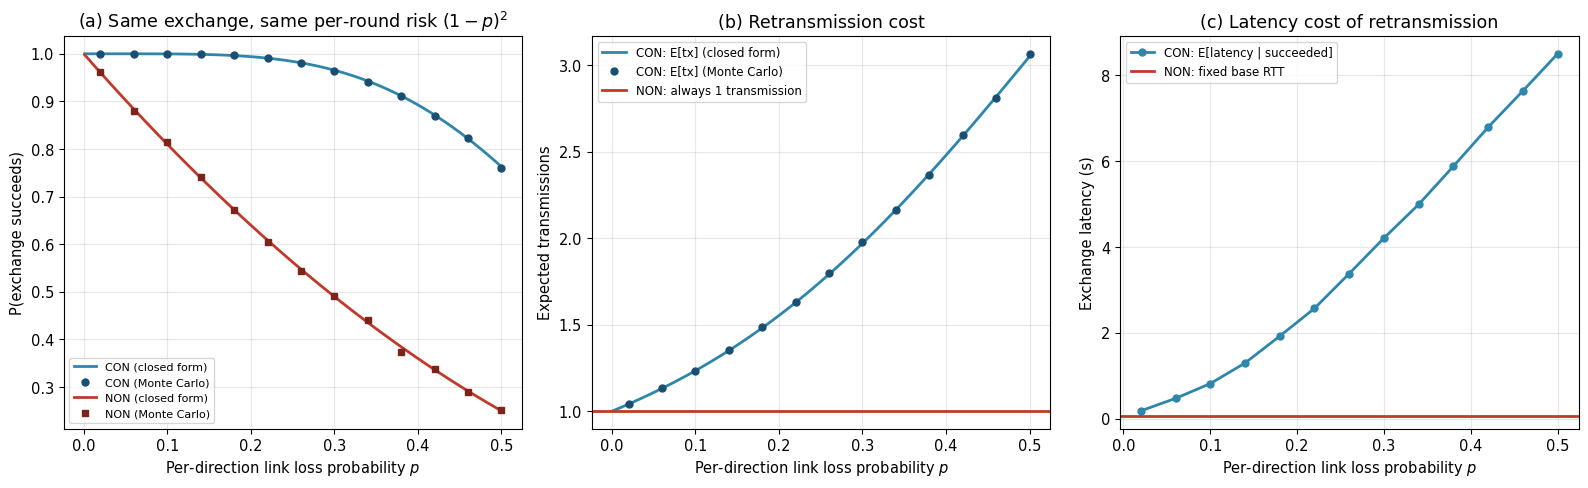

In [5]:
# ── Figure 24.2: success probability, retransmission cost, latency ─────
p_grid = np.linspace(0.001, 0.5, 60)
p_grid_sim = np.linspace(0.02, 0.5, 13)
con_analytic = [con_success_closed_form(p) for p in p_grid]
non_analytic = [non_success_closed_form(p) for p in p_grid]
etx_analytic = [con_expected_tx_closed_form(p) for p in p_grid]

con_sim, non_sim, etx_sim, lat_sim = [], [], [], []
for p in p_grid_sim:
    cs, ctx, cl = simulate_exchange(p, "CON", 25000, np.random.default_rng(int(p*10000)+3))
    ns, ntx, nl = simulate_exchange(p, "NON", 25000, np.random.default_rng(int(p*10000)+4))
    con_sim.append(cs.mean()); non_sim.append(ns.mean())
    etx_sim.append(ctx.mean()); lat_sim.append(np.nanmean(cl))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
ax.plot(p_grid, con_analytic, '-', color='#2E86AB', lw=2, label='CON (closed form)')
ax.plot(p_grid_sim, con_sim, 'o', color='#1B4F72', ms=5, label='CON (Monte Carlo)')
ax.plot(p_grid, non_analytic, '-', color='#C0392B', lw=2, label='NON (closed form)')
ax.plot(p_grid_sim, non_sim, 's', color='#7B241C', ms=5, label='NON (Monte Carlo)')
ax.set_xlabel('Per-direction link loss probability $p$'); ax.set_ylabel('P(exchange succeeds)')
ax.set_title('(a) Same exchange, same per-round risk $(1-p)^2$'); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(p_grid, etx_analytic, '-', color='#2E86AB', lw=2, label='CON: E[tx] (closed form)')
ax.plot(p_grid_sim, etx_sim, 'o', color='#1B4F72', ms=5, label='CON: E[tx] (Monte Carlo)')
ax.axhline(1, color='#C0392B', lw=2, label='NON: always 1 transmission')
ax.set_xlabel('Per-direction link loss probability $p$'); ax.set_ylabel('Expected transmissions')
ax.set_title('(b) Retransmission cost'); ax.legend(fontsize=8.5)

ax = axes[2]
ax.plot(p_grid_sim, lat_sim, 'o-', color='#2E86AB', lw=2, ms=5, label='CON: E[latency | succeeded]')
ax.axhline(BASE_RTT, color='#C0392B', lw=2, label='NON: fixed base RTT')
ax.set_xlabel('Per-direction link loss probability $p$'); ax.set_ylabel('Exchange latency (s)')
ax.set_title('(c) Latency cost of retransmission'); ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig('fig_24_2_con_vs_non.png', dpi=300, bbox_inches='tight')
plt.show()

### Analysis

Because both message types face the identical $(1-p)^2$ per-round risk,
the entire gap between the curves in **Figure 24.2(a)** is the effect of
retrying: at $p=0.20$, CON succeeds 99.3% of the time against NON's
64.0%; at $p=0.30$, CON still succeeds 96.6% against NON's 49.0% —
barely better than a coin flip, for the *same* underlying exchange,
purely because NON gets one attempt.

**Figure 24.2(b)** shows the transmission cost of that reliability: near
1 at low loss, climbing past 1.5 around $p=0.15$–$0.20$ toward the
5-transmission ceiling.

**Figure 24.2(c)** shows the timing cost is steeper still: at $p=0.20$
a successful CON exchange takes 2.27 s on average — more than 28× NON's
~80 ms base RTT — because a single lost round already forces a
multi-second wait, and the timeout doubles again on every retry.

> **Key takeaway.** Once CON and NON are compared as the same exchange,
> the whole measured gap is attributable to retransmission alone. NON
> suits genuinely tolerable, silent loss; CON suits an application that
> needs to *know* whether the exchange completed, at a quantified
> latency cost.

### Challenge tasks

1. Extend the simulator to accept independent $p_{\text{req}}$,
   $p_{\text{resp}}$ and determine which direction dominates latency.
2. Recompute $P_{\text{CON}}$ and $E[\text{latency}]$ at $p=0.30$ for
   `MAX_RETRANSMIT` = 2, 4, 6. Is the 5th/6th transmission worth it?
3. Model `NSTART`=2 for 10 back-to-back readings with independent
   backoff timers.
4. Model duty-cycled (rather than independently lossy) endpoints and
   compare the resulting $P(\text{succeeds})$ curve to this exercise's
   independent-loss model at the same nominal average loss rate.

---
## Exercise 24.3 — Observe: a Full Lifecycle Model

### Background

RFC 7641's Observe Option lets a server push a notification whenever a
resource actually changes, instead of a client polling repeatedly.
Max-Age describes how long a representation may be considered fresh
once received. It is not itself a delivery guarantee: nothing obliges a
*server* to refresh a quiet resource before Max-Age expires, and even a
client that does decide to revalidate once that period elapses has no
guarantee the revalidating exchange itself succeeds. This exercise
models the client as the party responsible for that freshness policy:
notifications are sent only on genuine changes, and it is the *client*
that issues a revalidating GET whenever it needs a value and the last
notification has aged past Max-Age. The renewal model below is an
**idealised freshness policy under loss-free, immediately successful
revalidation** — a stated simplification, alongside another: RFC 7641
recommends a randomised 5–15 s delay before a post-expiry GET, to avoid
many clients revalidating in lockstep, where this model issues that GET
immediately.

**Renewal-process model.** With changes as a Poisson process (rate
$\lambda$/hour $= \lambda_s$/second, $\lambda_s=\lambda/3600$) and a
client revalidating whenever the gap would exceed Max-Age $M$ (seconds),
each cycle has length $\min(X, M)$, $X\sim\text{Exp}(\lambda_s)$:

$$E[\text{cycle}] = \frac{1-e^{-\lambda_s M}}{\lambda_s}, \quad
P(\text{change}) = 1-e^{-\lambda_s M}, \quad P(\text{revalidation}) = e^{-\lambda_s M}$$

**Byte-exact accounting, including Max-Age on every message.** RFC 7641
§4.2 requires a Max-Age Option on every notification, and a
registration/revalidation response carries one too — so message sizes
depend on the *configured Max-Age value itself*, not a single constant.

**Stated simplification:** one notification per genuine change is an
*upper bound* — RFC 7641 permits a server to coalesce rapid changes and
notify only the latest state.

In [6]:
# ── Exercise 24.3: renewal-process traffic model + byte-exact accounting ──
DAY_S = 86400.0
URI_SEGMENTS = ("sensors", "temperature")
TOKEN = bytes([0x11, 0x22])
EMPTY_ACK_BYTES = 4

def renewal_stats(lambda_per_hour, max_age_s):
    lam_s = lambda_per_hour / 3600.0          # convert to changes/second, matching max_age_s's units
    if lam_s == 0:
        return max_age_s, 0.0, 1.0
    p_change = 1 - np.exp(-lam_s * max_age_s)
    e_cycle = (1 - np.exp(-lam_s * max_age_s)) / lam_s
    return e_cycle, p_change, 1 - p_change

def daily_cycles(lam, max_age):
    return DAY_S / renewal_stats(lam, max_age)[0]

def daily_notifications_and_revalidations(lam, max_age):
    n = daily_cycles(lam, max_age)
    _, p_c, p_r = renewal_stats(lam, max_age)
    return n * p_c, n * p_r

def simulate_renewal_process(lambda_per_hour, max_age_s, n_cycles, rng):
    """Direct Monte Carlo simulation of the renewal process: draw
    n_cycles exponential inter-change times and cap each at max_age_s."""
    lam_s = lambda_per_hour / 3600.0
    x = rng.exponential(1.0 / lam_s, size=n_cycles)
    cycle_len = np.minimum(x, max_age_s)
    is_change = x <= max_age_s
    return cycle_len.mean(), is_change.mean()

def registration_or_revalidation_bytes(osn_value, max_age_s):
    req_options = sorted([(6, b"")] + [(11, s.encode()) for s in URI_SEGMENTS], key=lambda kv: kv[0])
    request = encode_coap_message(0, coap_code(0, 1), 0x1000, TOKEN, req_options)
    resp_options = sorted([(6, osn_value), (12, uint_option_value(0)), (14, uint_option_value(max_age_s))],
                           key=lambda kv: kv[0])
    response = encode_coap_message(2, coap_code(2, 5), 0x1000, TOKEN, resp_options, b"22.5")
    return len(request), len(response)

def notification_bytes(msg_type, osn_value, max_age_s):
    mt = 0 if msg_type == "CON" else 1
    options = sorted([(6, osn_value), (12, uint_option_value(0)), (14, uint_option_value(max_age_s))],
                      key=lambda kv: kv[0])
    notif = encode_coap_message(mt, coap_code(2, 5), 0x2000, TOKEN, options, b"22.5")
    return len(notif) + (EMPTY_ACK_BYTES if msg_type == "CON" else 0)

OSN_TYPICAL, OSN_INITIAL = uint_option_value(1000), uint_option_value(0)

def registration_bytes(max_age_s):
    req, resp = registration_or_revalidation_bytes(OSN_INITIAL, max_age_s)
    return req + resp

def revalidation_bytes(max_age_s):
    req, resp = registration_or_revalidation_bytes(OSN_TYPICAL, max_age_s)
    return req + resp

def con_notification_bytes(max_age_s):
    return notification_bytes("CON", OSN_TYPICAL, max_age_s)

def non_notification_bytes(max_age_s):
    return notification_bytes("NON", OSN_TYPICAL, max_age_s)

def observe_daily_bytes(lam, max_age, notif_type="NON"):
    n_notif, n_reval = daily_notifications_and_revalidations(lam, max_age)
    per = con_notification_bytes(max_age) if notif_type == "CON" else non_notification_bytes(max_age)
    return registration_bytes(max_age) + n_notif * per + n_reval * revalidation_bytes(max_age)

def polling_bytes_per_day(t_poll, exchange_bytes):
    return (DAY_S / t_poll) * exchange_bytes

print("Message sizes by Max-Age (Max-Age Option included in every message):")
for ma in [60, 900, 3600, 86400]:
    print(f"  MaxAge={ma:6d}s  registration={registration_bytes(ma)}B  "
          f"revalidation={revalidation_bytes(ma)}B  "
          f"NON notif={non_notification_bytes(ma)}B  CON notif+ACK={con_notification_bytes(ma)}B")
print()
for lam in [0.05, 0.5, 3, 12]:
    for ma in [60, 900, 3600]:
        n, r = daily_notifications_and_revalidations(lam, ma)
        print(f"lambda={lam:6.2f}/h  MaxAge={ma:5d}s  notif/day={n:7.1f}  reval/day={r:7.1f}")

Message sizes by Max-Age (Max-Age Option included in every message):
  MaxAge=    60s  registration=42B  revalidation=44B  NON notif=17B  CON notif+ACK=21B
  MaxAge=   900s  registration=43B  revalidation=45B  NON notif=18B  CON notif+ACK=22B
  MaxAge=  3600s  registration=43B  revalidation=45B  NON notif=18B  CON notif+ACK=22B
  MaxAge= 86400s  registration=44B  revalidation=46B  NON notif=19B  CON notif+ACK=23B

lambda=  0.05/h  MaxAge=   60s  notif/day=    1.2  reval/day= 1439.4
lambda=  0.05/h  MaxAge=  900s  notif/day=    1.2  reval/day=   95.4
lambda=  0.05/h  MaxAge= 3600s  notif/day=    1.2  reval/day=   23.4
lambda=  0.50/h  MaxAge=   60s  notif/day=   12.0  reval/day= 1434.0
lambda=  0.50/h  MaxAge=  900s  notif/day=   12.0  reval/day=   90.1
lambda=  0.50/h  MaxAge= 3600s  notif/day=   12.0  reval/day=   18.5
lambda=  3.00/h  MaxAge=   60s  notif/day=   72.0  reval/day= 1404.3
lambda=  3.00/h  MaxAge=  900s  notif/day=   72.0  reval/day=   64.5
lambda=  3.00/h  MaxAge= 3600s

In [7]:
# ── Monte Carlo validation of the renewal-process closed form ──────────
# Direct simulation: draw 200,000 exponential inter-change times per
# (lambda, Max-Age) pair, cap each at Max-Age, and compare the sampled
# mean cycle length and change-fraction against the closed form.
print("Renewal process: closed form vs. Monte Carlo (200,000 cycles per pair)")
print(f"{'lambda/h':>9s} {'MaxAge':>7s} {'E[cyc] closed':>14s} {'E[cyc] sim':>11s} "
      f"{'P(chg) closed':>14s} {'P(chg) sim':>11s}")
rng = np.random.default_rng(42)
max_rel_err = 0.0
for lam in [0.05, 0.5, 3, 12]:
    for ma in [60, 900, 3600]:
        closed_e, closed_p, _ = renewal_stats(lam, ma)
        sim_e, sim_p = simulate_renewal_process(lam, ma, 200000, rng)
        rel_err = abs(sim_e - closed_e) / closed_e
        max_rel_err = max(max_rel_err, rel_err)
        print(f"{lam:9.2f} {ma:7d} {closed_e:14.2f} {sim_e:11.2f} {closed_p:14.4f} {sim_p:11.4f}")
print(f"\nMax relative error in E[cycle] across all (lambda, Max-Age) pairs: {max_rel_err:.4f}")
assert max_rel_err < 0.02, "Monte Carlo estimate should match the closed form to within ~2% at n=200,000"
print("Closed form validated against direct Monte Carlo simulation.")

Renewal process: closed form vs. Monte Carlo (200,000 cycles per pair)
 lambda/h  MaxAge  E[cyc] closed  E[cyc] sim  P(chg) closed  P(chg) sim
     0.05      60          59.98       59.97         0.0008      0.0008
     0.05     900         894.40      894.38         0.0124      0.0125
     0.05    3600        3511.48     3511.29         0.0488      0.0485
     0.50      60          59.75       59.74         0.0083      0.0086
     0.50     900         846.02      846.42         0.1175      0.1164
     0.50    3600        2832.98     2833.39         0.3935      0.3938
     3.00      60          58.52       58.56         0.0488      0.0477
     3.00     900         633.16      632.32         0.5276      0.5290
     3.00    3600        1140.26     1138.75         0.9502      0.9502
    12.00      60          54.38       54.39         0.1813      0.1811
    12.00     900         285.06      285.07         0.9502      0.9503
    12.00    3600         300.00      299.98         1.0000      

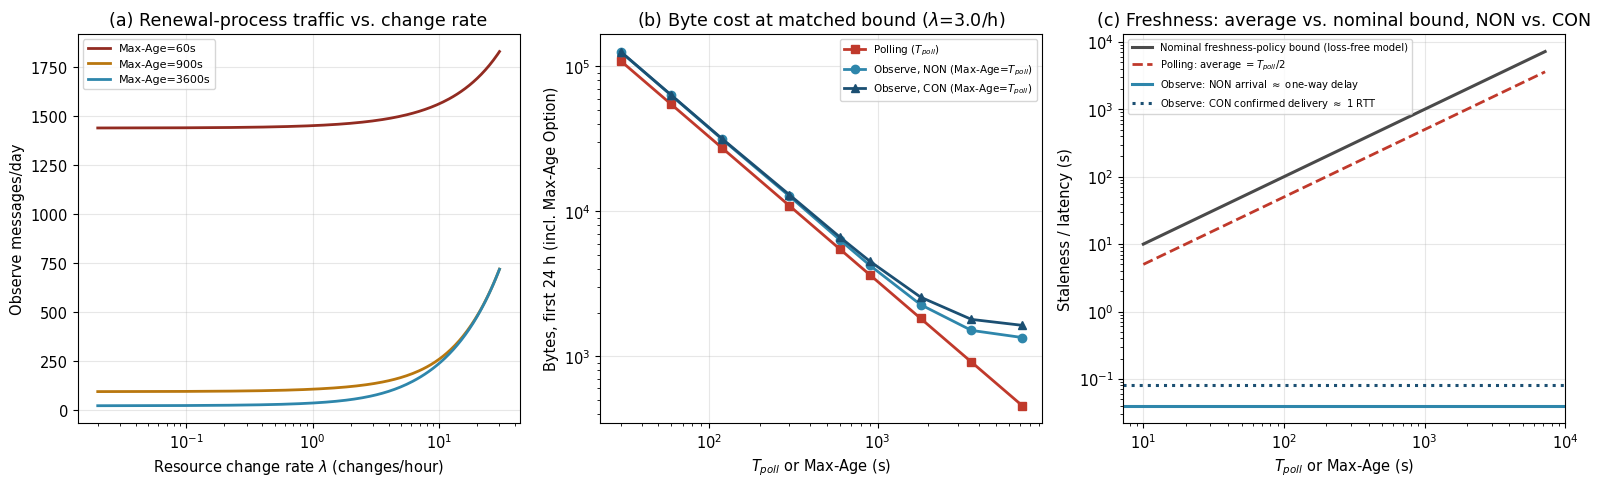


Observe, Max-Age=86400s (1 day), lambda=3/h: 1412 B in the first 24h (incl. one-time registration; 1368 B/day from day 2 onward)
  vs. Polling T_poll=60s: 54720 B/day  (ratio Observe/Polling = 0.026)
  vs. Polling T_poll=300s: 10944 B/day  (ratio Observe/Polling = 0.129)
  vs. Polling T_poll=900s: 3648 B/day  (ratio Observe/Polling = 0.387)
  vs. Polling T_poll=3600s: 912 B/day  (ratio Observe/Polling = 1.548)


In [8]:
# ── Figure 24.3: renewal traffic, matched-bound bytes, freshness ──────
POLL_EXCHANGE_BYTES = len(build_coap_exchange()[0]) + len(build_coap_exchange()[1])  # 38B, no Observe option

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
lam_grid = np.logspace(np.log10(0.02), np.log10(30), 200)
for ma, color in [(60, '#922B21'), (900, '#B9770E'), (3600, '#2E86AB')]:
    tot = [sum(daily_notifications_and_revalidations(l, ma)) for l in lam_grid]
    ax.plot(lam_grid, tot, color=color, lw=2, label=f'Max-Age={ma}s')
ax.set_xscale('log')
ax.set_xlabel('Resource change rate $\\lambda$ (changes/hour)'); ax.set_ylabel('Observe messages/day')
ax.set_title('(a) Renewal-process traffic vs. change rate'); ax.legend(fontsize=8)

ax = axes[1]
t_grid = np.array([30, 60, 120, 300, 600, 900, 1800, 3600, 7200])
lam_fixed = 3.0
obs_non = [observe_daily_bytes(lam_fixed, int(t), "NON") for t in t_grid]
obs_con = [observe_daily_bytes(lam_fixed, int(t), "CON") for t in t_grid]
poll = [polling_bytes_per_day(int(t), POLL_EXCHANGE_BYTES) for t in t_grid]
ax.plot(t_grid, poll, 's-', color='#C0392B', lw=2, label='Polling ($T_{poll}$)')
ax.plot(t_grid, obs_non, 'o-', color='#2E86AB', lw=2, label='Observe, NON (Max-Age=$T_{poll}$)')
ax.plot(t_grid, obs_con, '^-', color='#1B4F72', lw=2, label='Observe, CON (Max-Age=$T_{poll}$)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('$T_{poll}$ or Max-Age (s)'); ax.set_ylabel('Bytes, first 24 h (incl. Max-Age Option)')
ax.set_title(f'(b) Byte cost at matched bound ($\\lambda$={lam_fixed}/h)'); ax.legend(fontsize=7.5)

ax = axes[2]
t_fine = np.logspace(np.log10(10), np.log10(7200), 200)
ax.plot(t_fine, t_fine, color='#4A4A4A', lw=2.2, label='Nominal freshness-policy bound (loss-free model)')
ax.plot(t_fine, t_fine/2, color='#C0392B', lw=2, ls='--', label='Polling: average $=T_{poll}/2$')
ax.axhline(BASE_RTT/2, color='#2E86AB', lw=2.2, label='Observe: NON arrival $\\approx$ one-way delay')
ax.axhline(BASE_RTT, color='#1B4F72', lw=2.2, ls=':', label='Observe: CON confirmed delivery $\\approx$ 1 RTT')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('$T_{poll}$ or Max-Age (s)'); ax.set_ylabel('Staleness / latency (s)')
ax.set_title('(c) Freshness: average vs. nominal bound, NON vs. CON'); ax.legend(fontsize=7.2)

plt.tight_layout()
plt.savefig('fig_24_3_observe_vs_polling.png', dpi=300, bbox_inches='tight')
plt.show()

obs_loose = observe_daily_bytes(3.0, 86400, "NON")
print(f"\nObserve, Max-Age=86400s (1 day), lambda=3/h: {obs_loose:.0f} B in the first 24h "
      f"(incl. one-time registration; {obs_loose - registration_bytes(86400):.0f} B/day from day 2 onward)")
for tp in [60, 300, 900, 3600]:
    pb = polling_bytes_per_day(tp, POLL_EXCHANGE_BYTES)
    print(f"  vs. Polling T_poll={tp}s: {pb:.0f} B/day  (ratio Observe/Polling = {obs_loose/pb:.3f})")

In [9]:
# ── OSN comparison rule and reordering (RFC 7641 Sec. 3.4) ─────────────
# This implements the serial-number component of the RFC's comparison
# rule, which applies for notifications separated by less than 128 s.
# RFC 7641 adds a third, time-based branch for gaps beyond 128 s (a new
# notification is then accepted as newer regardless of the
# serial-number test); the demonstration below sends notifications
# closely spaced in time, so only the serial-number branches fire.
def osn_is_newer(v1_prev, v2_new, t1_prev=None, t2_new=None):
    if v1_prev < v2_new and (v2_new - v1_prev) < (1 << 23):
        return True
    if v1_prev > v2_new and (v1_prev - v2_new) > (1 << 23):
        return True
    if t1_prev is not None and t2_new is not None and t2_new > t1_prev + 128:
        return True
    return False

def simulate_reordering(n, p_reorder, rng):
    order = np.arange(n); i = 0
    while i < len(order) - 1:
        if rng.random() < p_reorder:
            order[i], order[i+1] = order[i+1], order[i]; i += 2
        else:
            i += 1
    last, accepted, rejected = -1, 0, 0
    for osn in order:
        if last == -1 or osn_is_newer(last, osn):
            last = osn; accepted += 1
        else:
            rejected += 1
    return accepted, rejected

rng = np.random.default_rng(7)
for p_reorder in [0.0, 0.05, 0.15, 0.30]:
    acc, rej = simulate_reordering(2000, p_reorder, rng)
    print(f"p_reorder={p_reorder:.2f}  accepted={acc}  correctly rejected (stale)={rej}")

p_reorder=0.00  accepted=2000  correctly rejected (stale)=0
p_reorder=0.05  accepted=1911  correctly rejected (stale)=89
p_reorder=0.15  accepted=1720  correctly rejected (stale)=280
p_reorder=0.30  accepted=1556  correctly rejected (stale)=444


### Analysis

**Figure 24.3(a)** shows the model's central finding: at Max-Age=60 s,
total traffic stays near 1440 msgs/day *regardless of $\lambda$*,
dominated by client revalidations — almost exactly what 60-second
polling would cost. Only at Max-Age=3600 s does the notification count
dominate and traffic collapse toward genuine changes.

**Figure 24.3(b)** shows that at a matched nominal bound
(Max-Age=$T_{\text{poll}}$), Observe costs slightly *more* than
polling, not less — the revalidation floor alone already costs about
what polling would, and both notifications and every message's own
Max-Age Option add to it. Observe's advantage (**Figure 24.3(c)**) is
freshness at that same cost: a NON notification arrives after roughly
one one-way delay; a CON notification's *confirmed* delivery takes
roughly one RTT; both are far below polling's $T_{\text{poll}}/2$
average detection delay.

The loose-Max-Age comparison above (Max-Age=86400 s, $\lambda=3$/h,
measured over the first 24 hours including the one-time registration)
shows Observe costing ~39× less than 60-second polling and ~8× less
than 300-second polling — *while also* delivering far better typical
freshness than either. Only once polling itself is relaxed well past
Observe's own Max-Age does polling's raw byte cost fall below
Observe's, at the price of an average staleness measured in tens of
minutes.

**OSN reordering:** the serial-number component of the RFC 7641 §3.4
rule correctly rejects every out-of-order, stale notification within
its scope (0 at $p_{\text{reorder}}=0$, rising through 89, 280, 444 out
of 2000 as reordering increases).

> **Key takeaway.** Max-Age is a client-consumed freshness policy, not
> a server heartbeat obligation, and every message that carries it —
> registration, revalidation, and each notification — pays for the
> Option itself. Observe's traffic advantage depends entirely on how
> loosely that policy is set; matched to the same nominal bound,
> Observe costs about the same as polling — its real value is
> near-instant freshness for that same cost.

### Challenge tasks

1. Model a resource with a strong diurnal pattern; does one fixed
   Max-Age serve both regimes well?
2. Model a "lazy" client that only revalidates when it next needs the
   value, and recompute the table for hourly checks.
3. Sweep $\lambda$ and Max-Age jointly; plot the breakeven curve against
   a chosen polling baseline.
4. Extend `osn_is_newer` to exercise its third (time-based) branch by
   simulating notifications more than 128 seconds apart, and confirm it
   accepts a new notification even when the serial-number test alone
   would not.

---
## Exercise 24.4 — Blockwise Transfer: Reliability and Time Under a Lossy Link

### Background

RFC 7959's Blockwise Transfer splits a payload too large for one
datagram into blocks, each its own CoAP exchange tagged with a Block2
Option (NUM, M, SZX). This exercise models a sequential GET-based
transfer (`NSTART`=1): each block is a Confirmable exchange with an
immediate, piggybacked response, retried with exponential backoff, and
**a block that exhausts its retry budget fails the entire transfer** —
it does not silently continue to the next block.

**Asymmetric loss.** A block exchange has two very differently sized
frames — a small request (Uri-Path + Block2, no payload) and a much
larger response (Block2 + payload). Each gets its own loss probability
from its own true byte-exact size:

$$p_{\text{bit}} = 1-(1-p_{\text{ref}})^{1/(8F_{\max})}, \qquad p_{\text{loss}}(L) = 1-(1-p_{\text{bit}})^{8L}$$

**Per-block byte accounting.** The Block2 Option's encoded length grows
with the true block number NUM (1 byte while NUM<16, 2 bytes while
NUM<4096, 3 bytes beyond) — computed here for *every block individually*,
not assumed from block 0 alone, since a 4096-B transfer at a 16-B block
size needs 256 blocks whose NUM runs well past that first boundary.
Separately, a response's bytes are counted as transmitted the moment
the request that triggers it arrives — the server has physically sent
them, using real airtime and energy, whether or not that response then
survives the trip back — rather than only when the block ultimately
succeeds.

In [10]:
# ── Exercise 24.4: Blockwise Transfer simulator ────────────────────────
FW_URI = ("files", "log-batch")
FW_TOKEN = bytes([0x30, 0x31])
SZX_VALUES = list(range(0, 7))
BLOCK_SIZES = [2 ** (szx + 4) for szx in SZX_VALUES]     # 16..1024 B

def block2_option_value(num, more, szx):
    return uint_option_value((num << 4) | ((1 if more else 0) << 3) | szx)

def block_request_bytes(block_num, szx):
    """CON GET for one block: Uri-Path + Block2(NUM, M=0, SZX)."""
    options = sorted([(11, s.encode()) for s in FW_URI] + [(23, block2_option_value(block_num, False, szx))],
                      key=lambda kv: kv[0])
    return len(encode_coap_message(0, coap_code(0, 1), 0x5000 + block_num, FW_TOKEN, options))

def block_response_bytes(block_num, szx, more, payload_len):
    """Piggybacked 2.05 Content response (Type=ACK, same Message ID as the request)."""
    options = [(23, block2_option_value(block_num, more, szx))]
    return len(encode_coap_message(2, coap_code(2, 5), 0x5000 + block_num, FW_TOKEN, options, b"x" * payload_len))

def n_blocks(payload_len, block_size):
    return int(np.ceil(payload_len / block_size))

_max_block_response_bytes = block_response_bytes(0, 6, True, 1024)   # calibration frame

def frame_loss_probability(frame_bytes, p_ref):
    p_bit = 1 - (1 - p_ref) ** (1 / (8 * _max_block_response_bytes))
    return 1 - (1 - p_bit) ** (8 * frame_bytes)

def simulate_transfer(payload_len, block_size, p_ref, n_trials, rng):
    """Sequential Blockwise Transfer (NSTART=1), vectorised across trials
    for speed: numpy array operations replace a per-trial Python loop
    at each of the small, fixed number of (block, attempt) steps."""
    szx = int(np.log2(block_size)) - 4
    nb = n_blocks(payload_len, block_size)
    last_size = payload_len - block_size * (nb - 1)

    req_bytes_arr = np.empty(nb, dtype=np.int64)
    resp_bytes_arr = np.empty(nb, dtype=np.int64)
    p_req_arr = np.empty(nb); p_resp_arr = np.empty(nb)
    for b in range(nb):
        is_last = (b == nb - 1)
        req_bytes_arr[b] = block_request_bytes(b, szx)
        resp_bytes_arr[b] = block_response_bytes(b, szx, not is_last, last_size if is_last else block_size)
        p_req_arr[b] = frame_loss_probability(req_bytes_arr[b], p_ref)
        p_resp_arr[b] = frame_loss_probability(resp_bytes_arr[b], p_ref)

    total_bytes = np.zeros(n_trials)
    total_time = np.zeros(n_trials)
    active = np.ones(n_trials, dtype=bool)   # trials whose transfer has not yet failed

    for b in range(nb):
        req_bytes, resp_bytes = int(req_bytes_arr[b]), int(resp_bytes_arr[b])
        p_req, p_resp = p_req_arr[b], p_resp_arr[b]
        t0 = rng.uniform(ACK_TIMEOUT, ACK_TIMEOUT * ACK_RANDOM_FACTOR, size=n_trials)   # fresh per block

        block_done = np.zeros(n_trials, dtype=bool)
        for attempt in range(MAX_RETRANSMIT + 1):
            doing = active & ~block_done
            if not doing.any():
                break
            req_ok = np.zeros(n_trials, dtype=bool)
            req_ok[doing] = rng.random(int(doing.sum())) > p_req
            total_bytes[doing] += req_bytes                  # request always transmitted

            arrived = doing & req_ok
            total_bytes[arrived] += resp_bytes                # response sent as soon as request arrives
            resp_ok = np.zeros(n_trials, dtype=bool)
            resp_ok[arrived] = rng.random(int(arrived.sum())) > p_resp

            succeeded_now = arrived & resp_ok
            total_time[succeeded_now] += BASE_RTT
            block_done |= succeeded_now

            waiting = doing & ~succeeded_now
            total_time[waiting] += t0[waiting] * (2 ** attempt)

        active = active & block_done   # trials that exhausted this block's retries drop out here

    return active, total_bytes, total_time, nb

print("Calibration frame (SZX=6, 1024B block, M=1):", _max_block_response_bytes, "bytes")
print("Request bytes, block 0:", block_request_bytes(0, 6))
print("\nBlock Option growth with NUM (SZX=0, 16B blocks):")
for num in [0, 15, 16, 100, 255]:
    print(f"  NUM={num:4d}  request bytes={block_request_bytes(num, 0)}")

Calibration frame (SZX=6, 1024B block, M=1): 1034 bytes
Request bytes, block 0: 24

Block Option growth with NUM (SZX=0, 16B blocks):
  NUM=   0  request bytes=23
  NUM=  15  request bytes=24
  NUM=  16  request bytes=25
  NUM= 100  request bytes=25
  NUM= 255  request bytes=25


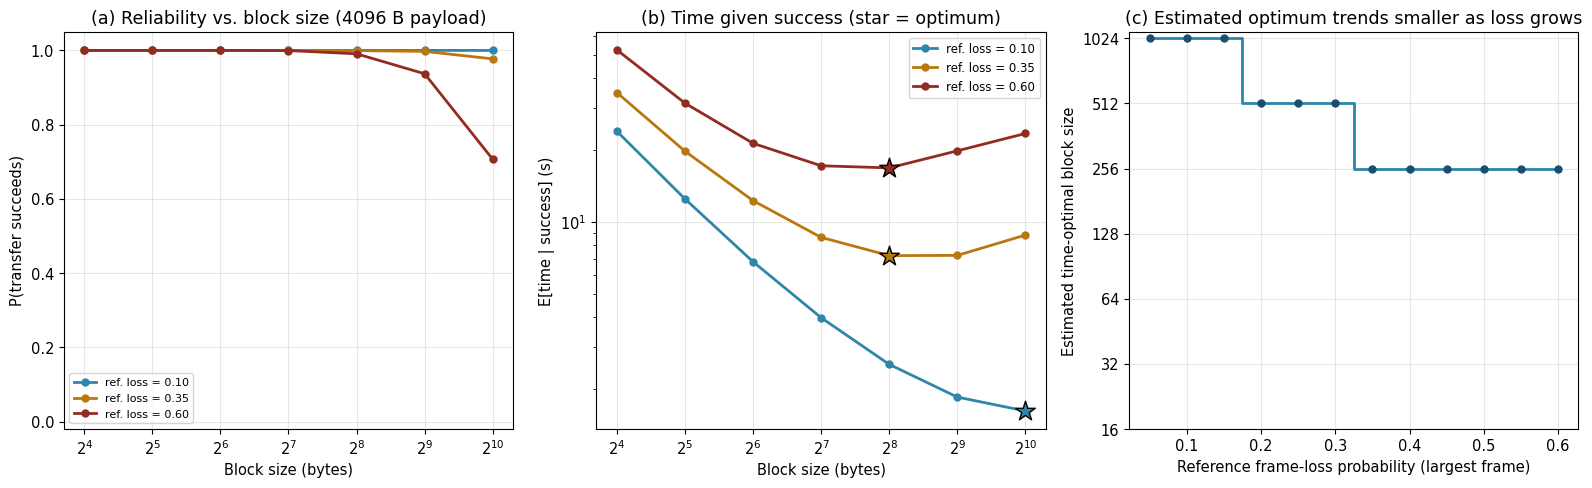

p_ref=0.1
     16B  P(succ)=1.0000  E[bytes|s]=13332  E[time|s]=23.884
     32B  P(succ)=1.0000  E[bytes|s]=8718  E[time|s]=12.452
     64B  P(succ)=1.0000  E[bytes|s]=6421  E[time|s]=6.798
    128B  P(succ)=1.0000  E[bytes|s]=5294  E[time|s]=3.967
    256B  P(succ)=1.0000  E[bytes|s]=4771  E[time|s]=2.531
    512B  P(succ)=1.0000  E[bytes|s]=4609  E[time|s]=1.847
   1024B  P(succ)=0.9999  E[bytes|s]=4708  E[time|s]=1.616
p_ref=0.35
     16B  P(succ)=1.0000  E[bytes|s]=13495  E[time|s]=34.653
     32B  P(succ)=1.0000  E[bytes|s]=8863  E[time|s]=19.711
     64B  P(succ)=1.0000  E[bytes|s]=6588  E[time|s]=12.242
    128B  P(succ)=1.0000  E[bytes|s]=5534  E[time|s]=8.597
    256B  P(succ)=0.9994  E[bytes|s]=5190  E[time|s]=7.212
    512B  P(succ)=0.9973  E[bytes|s]=5430  E[time|s]=7.227
   1024B  P(succ)=0.9771  E[bytes|s]=6400  E[time|s]=8.790
p_ref=0.6
     16B  P(succ)=1.0000  E[bytes|s]=13748  E[time|s]=52.276
     32B  P(succ)=1.0000  E[bytes|s]=9082  E[time|s]=31.301
     64B  P(suc

In [11]:
# ── Figure 24.4: reliability, time optimum, optimal-size trend ────────
PAYLOAD = 4096
P_REFS = [0.10, 0.35, 0.60]
COLORS = {0.10: '#2E86AB', 0.35: '#B9770E', 0.60: '#922B21'}
N_TRIALS = 7000

results = {p: {'psucc': [], 'ebytes': [], 'etime': []} for p in P_REFS}
for p in P_REFS:
    for bs in BLOCK_SIZES:
        succ, tb, tt, nb = simulate_transfer(PAYLOAD, bs, p, N_TRIALS, np.random.default_rng(bs*13+int(p*1000)+1))
        results[p]['psucc'].append(succ.mean())
        results[p]['ebytes'].append(tb[succ].mean() if succ.any() else np.nan)
        results[p]['etime'].append(tt[succ].mean() if succ.any() else np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for p in P_REFS:
    ax.plot(BLOCK_SIZES, results[p]['psucc'], 'o-', color=COLORS[p], lw=2, ms=5, label=f'ref. loss = {p:.2f}')
ax.set_xscale('log', base=2)
ax.set_xlabel('Block size (bytes)'); ax.set_ylabel('P(transfer succeeds)')
ax.set_title(f'(a) Reliability vs. block size ({PAYLOAD} B payload)'); ax.legend(fontsize=8); ax.set_ylim(-0.02, 1.05)

ax = axes[1]
for p in P_REFS:
    ax.plot(BLOCK_SIZES, results[p]['etime'], 'o-', color=COLORS[p], lw=2, ms=5, label=f'ref. loss = {p:.2f}')
    oi = int(np.nanargmin(results[p]['etime']))
    ax.scatter([BLOCK_SIZES[oi]], [results[p]['etime'][oi]], marker='*', s=220, color=COLORS[p], edgecolor='black', zorder=5)
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xlabel('Block size (bytes)'); ax.set_ylabel('E[time | success] (s)')
ax.set_title('(b) Time given success (star = optimum)'); ax.legend(fontsize=8.5)

ax = axes[2]
p_fine = np.linspace(0.05, 0.6, 12)
opt_sizes = []
for p in p_fine:
    times = []
    for bs in BLOCK_SIZES:
        succ, tb, tt, nb = simulate_transfer(PAYLOAD, bs, p, 7000, np.random.default_rng(int(bs*5+p*3000)+11))
        times.append(tt[succ].mean() if succ.any() else np.inf)
    opt_sizes.append(BLOCK_SIZES[int(np.argmin(times))])
ax.step(p_fine, opt_sizes, where='mid', color='#2E86AB', lw=2)
ax.scatter(p_fine, opt_sizes, color='#1B4F72', s=25, zorder=5)
ax.set_yscale('log', base=2); ax.set_yticks(BLOCK_SIZES); ax.set_yticklabels(BLOCK_SIZES)
ax.set_xlabel('Reference frame-loss probability (largest frame)'); ax.set_ylabel('Estimated time-optimal block size')
ax.set_title('(c) Estimated optimum trends smaller as loss grows')

plt.tight_layout()
plt.savefig('fig_24_4_blockwise_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

for p in P_REFS:
    print(f"p_ref={p}")
    for i, bs in enumerate(BLOCK_SIZES):
        print(f"  {bs:5d}B  P(succ)={results[p]['psucc'][i]:.4f}  "
              f"E[bytes|s]={results[p]['ebytes'][i]:.0f}  E[time|s]={results[p]['etime'][i]:.3f}")

### Analysis

**Figure 24.4(a)** shows that the largest block is not just slower when
it succeeds — it measurably fails to complete the transfer more often.
At $p_{\text{ref}}=0.60$, a 1024-B-block transfer succeeds only 70.7% of
the time, against a 16-B-block transfer's 100.0%.

This reflects a genuine competition between two effects, not a
one-sided story. A larger block is an individually riskier datagram
(loss probability grows with frame size), so a 1024-B response is
substantially more likely to be lost on any given attempt than a 16-B
response. In the opposite direction, a smaller block size needs far
more blocks — 256 sixteen-byte blocks against 4 thousand-twenty-four-byte
blocks here — and the transfer only succeeds if *every* block succeeds
within its own budget, so more blocks means more independent chances
for at least one to exhaust it. Which effect wins is empirical, not
foregone: under this exercise's frame-size-dependent loss model, the
first effect dominates the second at every level tested — a handful of
individually risky large blocks fails more often in aggregate than many
individually safer small blocks, even though the small-block transfer
needs all of them to succeed.

Byte accounting that counts a lost response's bytes as spent also
matters at every loss level, not just high loss: 512 B costs fewer
expected bytes than 1024 B even at $p_{\text{ref}}=0.10$ (4609 vs.
4708), because every response a server transmits is counted, including
the ones a large block occasionally still loses and must retransmit in
full.

**Figure 24.4(b)** shows an interior time optimum only where that
reliability effect is large enough to matter — none at
$p_{\text{ref}}=0.10$ (bigger is simply faster and equally reliable),
an optimum near 256 B at $p_{\text{ref}}=0.35$ and $0.60$.

**Figure 24.4(c)** traces the *estimated* time-optimal block size across
a finer sweep — for the loss model and sampled values used here, the
estimate trends toward smaller blocks as loss grows. This is an
empirical trend from a finite number of Monte Carlo points without a
formal confidence interval, not a proven monotonic law; a ranking this
close between neighbouring sizes can plausibly reorder at a different
seed, and a real deployment decision should use a bootstrap interval or
an analytical per-block success probability rather than a single point
estimate.

**A boundary this model doesn't cover:** on a genuinely constrained
IEEE 802.15.4/6LoWPAN link (127-byte PHY MTU, ~80–100-byte usable
payload after header compression), a 1024-byte CoAP block would already
require roughly ten or more link-layer fragments — a risk this
CoAP-level model cannot see.

> **Key takeaway.** Blockwise Transfer's optimal block size is set by a
> genuine competition between per-block header overhead (favouring
> large blocks) and aggregate transfer reliability (increasingly
> favouring small blocks under loss) — not because a large block gets
> fewer retries (every block gets the same budget), but because it is
> individually more likely to need them, and that effect wins out over
> the sheer number of chances a small-block transfer offers for
> something to go wrong. This is exactly why RFC 7959 makes SZX
> negotiable, and why RFC 9177's Q-Block1/Q-Block2 exist as a further
> NON-based option.

### Challenge tasks

1. Sketch how you would model RFC 9177's Q-Block2 (NON-based, bulk
   recovery) and predict which panel would change most.
2. Add a size-independent loss floor (e.g. 1%) and find where small
   blocks stop being competitive.
3. Recompute for a 64 KB payload; does the $p_{\text{ref}}=0.35$
   optimum change, and why (which cost scales with payload size)?
4. Design an adaptive policy that halves block size after two
   consecutive failures; simulate it against the fixed-size baselines.

---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|--------------------|
| 24.1 | Byte-exact CoAP/HTTP encoder (full RFC 7252 §3.1 escape), payload/option sweeps | Shows CoAP's overhead advantage is real but payload- and URI-shape-dependent, not a fixed percentage |
| 24.2 | Unified CON/NON exchange simulation, validated vs. closed form | Isolates retransmission as the sole source of CON's reliability advantage over NON |
| 24.3 | Renewal-process Observe traffic model, byte-exact per-message-type accounting | Distinguishes Max-Age freshness semantics from an optional server-side heartbeat policy; reframes Observe's advantage as freshness, not raw traffic reduction |
| 24.4 | Asymmetric, frame-size-dependent Blockwise Transfer simulation with explicit failure tracking | Shows transfer *reliability*, not only speed, degrades for large blocks under loss |

### Where this leaves the protocol

Every byte count in this notebook comes from the same underlying
byte-exact CoAP message encoder built in the Setup cell and Exercise
24.1 — never from an estimated or assumed constant. That discipline is
what surfaced each exercise's central, sometimes counter-intuitive
finding: Exercise 24.1's payload-dependent overhead ratio, Exercise
24.2's isolated retransmission effect, Exercise 24.3's client-driven
Max-Age semantics, and Exercise 24.4's NUM-dependent Block Option size
and reliability cliff. CoAP's mechanisms give an implementation the
*ability* to be efficient; realising that efficiency depends on
configuring them — message type, Max-Age, SZX — against the actual
resource behaviour and link quality involved, not on accepting an
inherited or default value uncritically.

### Reproducibility note

Exercise 24.1's byte counts and Exercise 24.3's renewal-process traffic
figures are deterministic closed-form calculations requiring no random
seed. Exercises 24.2 and 24.4 use NumPy's random-number generator with
fixed seeds for their Monte Carlo components; where a closed-form
expression exists, this notebook validates the simulation against it
directly. Every reader re-running this notebook end to end should
obtain results matching this chapter's printed tables and figures to
within ordinary Monte Carlo sampling variation.
